In [1]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings("ignore")

# Step 1: Identifying frequently used words and phrases in mentor feedback.
- N-gram analayses

In [2]:
# Read the dataset and drop all columns except mentor_feedback_text
train_df = pd.read_csv("data/train.csv")
train_df.head()

,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,...,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,...,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,...,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,...,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...
3,STU_000004,2019,22,2018,Computer Engineering,Tier 1,2.82,54.85,77.80,2,...,78.69,85.05,2,4,49,7,running,Reddit,89.97,Güçlü bir kodlama yeteneği ve backend geliştir...
4,STU_000005,2026,22,2026,Computer Engineering,Tier 3,2.28,72.25,71.97,1,...,27.22,84.29,1,0,119,13,football,X,92.46,Ürün analizi alanına olan tutkusu ve makine öğ...


In [3]:
# 1. Turkish Stopwords (Let's remove unnecessary words: and, or, with, for, etc.)
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

turkish_stopwords = set(stopwords.words("turkish"))
# You can also add extra unnecessary words of your own choosing.
extra_stop_words = ['bir', 'olarak', 'çok', 'da', 'de', 'ise', 'olan', 'bu', 'kadar', 'daha', 'ancak']
all_stop_words = turkish_stopwords.union(extra_stop_words)
feedbacks = train_df["mentor_feedback_text"].dropna().astype(str)


In [4]:
# ---------------------------------------------------------
# STEP 1: EXTRACTING UNIGRAMS (Especially for Adjectives and Nouns)
# ---------------------------------------------------------

print("--- Extracting Unigrams (Adjectives and Nouns) ---")
vectorizer_1 = CountVectorizer(stop_words=list(all_stop_words), max_features=30)
X_1 = vectorizer_1.fit_transform(feedbacks)
words_1 = pd.DataFrame(X_1.sum(axis=0), columns=vectorizer_1.get_feature_names_out()).T
words_1.columns = ["Frequency"]
print(words_1.sort_values(by="Frequency", ascending=False).head(10))
print("\n")


--- Extracting Unigrams (Adjectives and Nouns) ---
             Frequency
fazla             4966
proje             4721
teknik            4044
geliştirme        3547
iletişim          3348
dikkat            3281
veri              3180
güçlü             3131
takım             2972
konusundaki       2739




In [11]:
# ---------------------------------------------------------
# STEP 2: EXTRACTING BIGRAMS (Especially Ability Patterns)
# ---------------------------------------------------------

print("--- MOST COMMONLY USED BINARY WORDS (e.g., machine learning, data structures) ---")
vectorizer_2 = CountVectorizer(stop_words=list(all_stop_words), ngram_range=(2,2), max_features=30)
X_2 = vectorizer_2.fit_transform(feedbacks)
words_2 = pd.DataFrame(X_2.sum(axis=0), columns=vectorizer_2.get_feature_names_out()).T
words_2.columns = ['Frequency']
print(words_2.sort_values(by='Frequency', ascending=False).head(10))
print("\n")

--- MOST COMMONLY USED BINARY WORDS (e.g., machine learning, data structures) ---
                    Frequency
problem çözme            2446
proje kalitesi           1714
makine öğrenimi          1441
dikkat çekici            1396
takım çalışması          1230
yazılım geliştirme       1158
açık kaynak              1114
dikkat çekiyor           1098
veri yapıları             984
veri bilimi               894




In [8]:
# ---------------------------------------------------------
# STEP 3: EXTRACTING TRIGRAMS (Especially Constructive Criticism)
# ---------------------------------------------------------

print("--- MOST COMMONLY USED TRIGRAMS (e.g., should work harder) ---")

vectorizer_3 = CountVectorizer(stop_words=list(all_stop_words), ngram_range=(3,3), max_features=30)
X_3 = vectorizer_3.fit_transform(feedbacks)
words_3 = pd.DataFrame(X_3.sum(axis=0), columns=vectorizer_3.get_feature_names_out()).T
words_3.columns = ['Frequency']
print(words_3.sort_values(by='Frequency', ascending=False).head(10))

--- MOST COMMONLY USED TRIGRAMS (e.g., should work harder) ---
                             Frequency
makine öğrenimi konusundaki        474
iletişim takım çalışması           437
açık kaynak katkıları              356
veri yapıları konusundaki          333
kodlama problem çözme              323
veri bilimi alanında               323
yazılım geliştirme alanında        321
problem çözme becerileri           312
proje kalitesi üzerinde            303
veri bilimi alanındaki             283


In [13]:
words_1.to_csv('words_1.csv')
words_2.to_csv('words_2.csv')
words_3.to_csv('words_3.csv')

# Step 2: NLP Baseline

In [21]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

In [27]:
class NLPFeatureEngineer(BaseEstimator, TransformerMixin):
    """
        A custom converter class that extracts Natural Language Processing (NLP) based features using only the 'mentor_feedback_text' column.
    """
    def __init__(self):
        # 1. Ability Patterns
        self.tech_skills = [
            'makine öğrenimi', 'veri yapıları', 'veri bilimi', 'veri analizi', 
            'backend', 'frontend', 'bulut', 'yazılım', 'açık kaynak', 'github', 
            'sql', 'yapay zeka', 'arka uç',
            # Copied from the columns (scores) of the dataset.
            'devops', 'cloud', 'kodlama', 'problem çözme', 'algoritma',
            # Copied from target role column 
            'mobil', 'siber güvenlik', 'data', 'analist', 'mühendis', 'developer'
        ]
        self.soft_skills = [
            'iletişim', 'takım çalışması', 'problem çözme', 'mülakat', 'proje', 'takım',
            # Added from columns of the dataset
            'liderlik', 'sunum', 'ekip', 'zaman yönetimi', 'analitik düşünme', 'yönetim', 'ikna'
        ]

        # 2. Signal Patterns
        self.positive_signals = [
            'etkileyici', 'güçlü', 'dikkat çekici', 'dikkat çekiyor', 
            'dikkat çeken', 'sağlam temel', 'aday haline', 'yüksek',
            # Added 
            'başarılı', 'harika', 'potansiyeli', 'iyi seviyede', 'gelişimi çok iyi', 
            'mükemmel', 'tatmin edici', 'beklentileri aşıyor', 'yetkin'
        ]
        self.improvement_signals = [
            'faydalı olacaktır', 'fazla pratik', 'deneyim kazanması', 
            'pratik yapması', 'üzerinde fazla',
            # Most commen words
            'geliştirmeli', 'eksik', 'odaklanmalı', 'çalışmalı', 'yetersiz', 
            'zayıf', 'beklentilerin altında', 'artırmalı', 'ihtiyacı var'
        ]

        # 3. Contextual Patterns
        self.contrast_words = [
            'ancak', 'fakat', 'rağmen', 'gösterse de',
            'bununla birlikte', 'yine de', 'yalnız'
        ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Convert text to lowercase and fill in blanks with 'no_feedback'.
        feedback_lower = df['mentor_feedback_text'].fillna('no_feedback').astype(str).str.lower()

        # --- CALCULATION LOGIC ---
        # Increase the score if both the word 'ability' and the word 'signal' appear in the text.

        # Technical Praise and Criticism
        df['tech_praise_score'] = feedback_lower.apply(
            lambda text: sum(1for w in self.tech_skills if w in text and any(p in text for p in self.positive_signals))
        )
        df['tech_criticism_score'] = feedback_lower.apply(
            lambda text: sum(1 for w in self.tech_skills if w in text and any(n in text for n in self.improvement_signals))
        )

        # Social Skills: Praise and Criticism
        df['soft_praise_score'] = feedback_lower.apply(
            lambda text: sum(1 for w in self.soft_skills if w in text and any(p in text for p in self.positive_signals))
        )
        df['soft_criticism_score'] = feedback_lower.apply(
            lambda text: sum(1 for w in self.soft_skills if w in text and any(n in text for n in self.improvement_signals))
        )

        # Capturing the contrast (the beginning of the criticism)
        df['has_contrast'] = feedback_lower.apply(
            lambda text: 1 if any(c in text for c in self.contrast_words) else 0
        )

        # Basic Text Length Metrics
        df['feedback_word_count'] = feedback_lower.str.split().str.len()
        
        return df


In [28]:
# NLP sınıfını oluştur ve sadece train_df üzerinde test et
nlp_engineer = NLPFeatureEngineer()
df_nlp_eklenmis = nlp_engineer.transform(train_df)

# Çıkan yeni NLP skorlarını ve metni yan yana gör
print(df_nlp_eklenmis[['mentor_feedback_text', 'tech_praise_score', 'tech_criticism_score', 'has_contrast']].head())

                                         mentor_feedback_text  \
student_id                                                      
STU_000001  Proje kalitesi ve makine öğrenimi konusundaki ...   
STU_000002  Kodlama ve problem çözme becerileri gelişmekte...   
STU_000003  İleri düzey frontend geliştirme becerileri ile...   
STU_000004  Güçlü bir kodlama yeteneği ve backend geliştir...   
STU_000005  Ürün analizi alanına olan tutkusu ve makine öğ...   

            tech_praise_score  tech_criticism_score  has_contrast  
student_id                                                         
STU_000001                  4                     4             1  
STU_000002                  0                     3             1  
STU_000003                  1                     0             1  
STU_000004                  2                     0             1  
STU_000005                  1                     0             1  


# Train CatBoost method with NLP process / No Feature Selection

In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from catboost import CatBoostRegressor

RANDOM_STATE = 42
TARGET = "career_success_score"
ID_COL = "student_id"

# Dosya yolları
TRAIN_PATH = "data/train.csv"
TEST_PATH = "data/test_x.csv"
SUBMISSION_NAME = "submission_catboost_nlp_merged.csv"

pd.set_option("display.max_columns", 200)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train boyutu:", train_df.shape)
print("Test boyutu :", test_df.shape)

Train boyutu: (10000, 47)
Test boyutu : (10000, 46)


In [32]:
def add_missing_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    missing_cols = ["english_exam_score", "internship_duration_months", "portfolio_score",
                    "github_avg_stars", "open_source_contribution_count", "linkedin_profile_score", "hr_interview_score"]
    for col in missing_cols:
        if col in df.columns:
            df[f"{col}_was_missing"] = df[col].isna().astype(int)
    return df

def fill_missing_values(train: pd.DataFrame, test: pd.DataFrame):
    train = train.copy()
    test = test.copy()

    # 1) Grup medyanı ile staj süresi doldurma
    group_medians = train.groupby("internship_count")["internship_duration_months"].median()
    global_median = train["internship_duration_months"].median()
    for df in [train, test]:
        df["internship_duration_months"] = df["internship_duration_months"].fillna(df["internship_count"].map(group_medians)).fillna(global_median)

    # 2) Ortalama (Mean) ile doldurma
    for col in ["english_exam_score", "linkedin_profile_score", "hr_interview_score", "portfolio_score"]:
        if col in train.columns:
            fill_value = train[col].mean()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    # 3) Medyan (Median) ile doldurma
    for col in ["github_avg_stars", "open_source_contribution_count"]:
        if col in train.columns:
            fill_value = train[col].median()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    # 4) Kategorik boşlukları doldurma
    object_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()
    for col in object_cols:
        if col in test.columns:
            train[col] = train[col].fillna("Unknown")
            test[col] = test[col].fillna("Unknown")

    return train, test

In [33]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Tarih, Yaş ve Temel Beceriler
    df["years_since_graduation"] = df["application_year"] - df["graduation_year"]
    df["age_at_graduation"] = df["age"] - df["years_since_graduation"]
    df["is_recent_graduate"] = (df["years_since_graduation"] <= 1).astype(int)

    tech_cols = ["coding_score", "problem_solving_score", "data_structures_score", "sql_score", "machine_learning_score", "backend_score", "frontend_score", "cloud_score", "devops_score"]
    df["technical_skill_mean"] = df[tech_cols].mean(axis=1)
    
    soft_cols = ["communication_score", "teamwork_score", "leadership_score", "presentation_score", "linkedin_profile_score", "cv_quality_score", "hr_interview_score"]
    df["soft_skill_mean"] = df[soft_cols].mean(axis=1)

    # Proje ve Etkileşim Skorları (Senin önceki kodlarından)
    df["project_portfolio_score"] = (df["project_quality_score"] + df["portfolio_score"] + df["real_client_project_count"] * 5 + df["freelance_project_count"] * 3 + df["github_repo_count"] * 0.5 + df["github_avg_stars"] * 0.5 + df["open_source_contribution_count"] * 2)
    df["experience_score"] = (df["internship_count"] * 10 + df["internship_duration_months"] * 2 + df["freelance_project_count"] * 5 + df["real_client_project_count"] * 7)
    df["interview_conversion_rate"] = df["interviews_attended"] / (df["applications_sent"] + 1)
    df["visibility_index"] = (df["linkedin_profile_score"] * 0.4 + df["portfolio_score"] * 0.3 + (df["github_repo_count"] + df["github_avg_stars"] * 2) * 0.3)

    # CatBoost için string ve eksik veri yönetimi (Metin istatistikleri)
    df["mentor_feedback_len"] = df["mentor_feedback_text"].astype(str).str.len()
    df["mentor_feedback_word_count"] = df["mentor_feedback_text"].astype(str).str.split().str.len()
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

In [37]:
def add_nlp_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 1. Sözlükleri (Dictionary) Genişletilmiş Olarak Tanımlıyoruz
    tech_skills =[
            'makine öğrenimi', 'veri yapıları', 'veri bilimi', 'veri analizi', 
            'backend', 'frontend', 'bulut', 'yazılım', 'açık kaynak', 'github', 
            'sql', 'yapay zeka', 'arka uç',
            # Copied from the columns (scores) of the dataset.
            'devops', 'cloud', 'kodlama', 'problem çözme', 'algoritma',
            # Copied from target role column 
            'mobil', 'siber güvenlik', 'data', 'analist', 'mühendis', 'developer'
        ]
    soft_skills = [
            'iletişim', 'takım çalışması', 'problem çözme', 'mülakat', 'proje', 'takım',
            # Added from columns of the dataset
            'liderlik', 'sunum', 'ekip', 'zaman yönetimi', 'analitik düşünme', 'yönetim', 'ikna'
        ]
    positive_signals = [
            'etkileyici', 'güçlü', 'dikkat çekici', 'dikkat çekiyor', 
            'dikkat çeken', 'sağlam temel', 'aday haline', 'yüksek',
            # Added 
            'başarılı', 'harika', 'potansiyeli', 'iyi seviyede', 'gelişimi çok iyi', 
            'mükemmel', 'tatmin edici', 'beklentileri aşıyor', 'yetkin'
        ]
    improvement_signals = [
            'faydalı olacaktır', 'fazla pratik', 'deneyim kazanması', 
            'pratik yapması', 'üzerinde fazla',
            # Most commen words
            'geliştirmeli', 'eksik', 'odaklanmalı', 'çalışmalı', 'yetersiz', 
            'zayıf', 'beklentilerin altında', 'artırmalı', 'ihtiyacı var'
        ]
    contrast_words = [
            'ancak', 'fakat', 'rağmen', 'gösterse de',
            'bununla birlikte', 'yine de', 'yalnız'
        ]
    feedback_lower = df['mentor_feedback_text'].fillna('no_feedback').astype(str).str.lower()

    # 2. Mantıksal Sinyalleri Hesaplama (Bizim Yöntem)
    df['tech_praise_score'] = feedback_lower.apply(lambda text: sum(1 for w in tech_skills if w in text and any(p in text for p in positive_signals)))
    df['tech_criticism_score'] = feedback_lower.apply(lambda text: sum(1 for w in tech_skills if w in text and any(n in text for n in improvement_signals)))
    df['soft_praise_score'] = feedback_lower.apply(lambda text: sum(1 for w in soft_skills if w in text and any(p in text for p in positive_signals)))
    df['soft_criticism_score'] = feedback_lower.apply(lambda text: sum(1 for w in soft_skills if w in text and any(n in text for n in improvement_signals)))
    df['has_contrast'] = feedback_lower.apply(lambda text: 1 if any(c in text for c in contrast_words) else 0)
    
    return df

def add_text_svd_features(train: pd.DataFrame, test: pd.DataFrame):
    # Ekip arkadaşının yazdığı matematiksel vektör (TF-IDF) yöntemi
    train = train.copy()
    test = test.copy()

    tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)
    train_tfidf = tfidf.fit_transform(train["mentor_feedback_text"].fillna("").astype(str))
    test_tfidf = tfidf.transform(test["mentor_feedback_text"].fillna("").astype(str))

    svd = TruncatedSVD(n_components=10, random_state=RANDOM_STATE)
    train_svd = svd.fit_transform(train_tfidf)
    test_svd = svd.transform(test_tfidf)

    for i in range(train_svd.shape[1]):
        train[f"mentor_feedback_svd_{i}"] = train_svd[:, i]
        test[f"mentor_feedback_svd_{i}"] = test_svd[:, i]

    return train, test

In [38]:
# 1. Adım: Eksikleri işaretle ve doldur
train_tmp = add_missing_flags(train_df)
test_tmp = add_missing_flags(test_df)
train_tmp, test_tmp = fill_missing_values(train_tmp, test_tmp)

# 2. Adım: Arkadaşının Sayısal Özellikleri
train_fe = add_features(train_tmp)
test_fe = add_features(test_tmp)

# 3. Adım: Bizim NLP Mantığımız (Yepyeni Güç)
train_fe = add_nlp_features(train_fe)
test_fe = add_nlp_features(test_fe)

# 4. Adım: Arkadaşının TF-IDF Vektörleri
train_fe, test_fe = add_text_svd_features(train_fe, test_fe)

print("Tüm özellikler başarıyla çıkarıldı. İşleme hazır!")

Tüm özellikler başarıyla çıkarıldı. İşleme hazır!


In [39]:
# Verileri ayırma
y = train_fe[TARGET].copy()
DROP_COLS = [TARGET, ID_COL, "mentor_feedback_text"]

X = train_fe.drop(columns=[c for c in DROP_COLS if c in train_fe.columns])
X_test = test_fe.drop(columns=[c for c in [ID_COL, "mentor_feedback_text"] if c in test_fe.columns])
X_test = X_test.reindex(columns=X.columns) # Sıralamayı garantiye alma

# CatBoost'un en sevdiği şey: Kategorik Sütunların Belirtilmesi
cat_cols = ["department", "university_tier", "target_role", "hobby", "preferred_social_media_platform"]
cat_cols = [c for c in cat_cols if c in X.columns]

for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]

# CatBoost Parametreleri
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1800,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 6,
    "random_seed": RANDOM_STATE,
    "verbose": 300
}

# Cross Validation Eğitimi
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
test_preds = np.zeros(len(X_test))
fold_scores = []

print("CatBoost Modeli NLP özellikleriyle eğitiliyor...")
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):
    model = CatBoostRegressor(**cat_params)
    model.fit(X.iloc[train_idx], y.iloc[train_idx], cat_features=cat_feature_indices, 
              eval_set=(X.iloc[valid_idx], y.iloc[valid_idx]), use_best_model=True)
    
    valid_pred = model.predict(X.iloc[valid_idx])
    fold_rmse = mean_squared_error(y.iloc[valid_idx], valid_pred) ** 0.5
    fold_scores.append(fold_rmse)
    test_preds += model.predict(X_test) / 5 # Ortalama Alıyoruz

print(f"\n---> BİRLEŞTİRİLMİŞ CV RMSE: {np.mean(fold_scores):.5f} <---")

# Sonuçları Kaydetme (Leaderboard Formatı)
test_preds_clipped = np.clip(test_preds, 0, 100)
submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET: test_preds_clipped})
submission.to_csv(SUBMISSION_NAME, index=False)
print(f"Sıfır hata garantili dosya oluşturuldu: {SUBMISSION_NAME}")

CatBoost Modeli NLP özellikleriyle eğitiliyor...
0:	learn: 14.9921835	test: 14.9790540	best: 14.9790540 (0)	total: 46ms	remaining: 1m 22s
300:	learn: 8.4824174	test: 9.2573025	best: 9.2573025 (300)	total: 15.5s	remaining: 1m 17s
600:	learn: 7.7727916	test: 9.1032103	best: 9.1031680 (597)	total: 29.7s	remaining: 59.3s
900:	learn: 7.2068410	test: 9.0783374	best: 9.0783374 (900)	total: 44.6s	remaining: 44.5s
1200:	learn: 6.7058051	test: 9.0509263	best: 9.0504345 (1161)	total: 1m 1s	remaining: 30.7s
1500:	learn: 6.2398166	test: 9.0498454	best: 9.0441269 (1356)	total: 1m 17s	remaining: 15.5s
1799:	learn: 5.8089276	test: 9.0386795	best: 9.0379337 (1796)	total: 1m 32s	remaining: 0us

bestTest = 9.037933691
bestIteration = 1796

Shrink model to first 1797 iterations.
0:	learn: 14.9390709	test: 15.1931790	best: 15.1931790 (0)	total: 38.4ms	remaining: 1m 9s
300:	learn: 8.3984295	test: 9.3759251	best: 9.3759251 (300)	total: 15.5s	remaining: 1m 17s
600:	learn: 7.7578284	test: 9.2342919	best: 9.233

In [43]:
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import numpy as np

# 1. Kategorik Değişkenleri XGBoost ve LightGBM'in sevdiği 'category' tipine çevirelim
cat_cols = ["department", "university_tier", "target_role", "hobby", "preferred_social_media_platform"]
cat_cols = [c for c in cat_cols if c in X.columns]

for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 2. Modelleri Tanımlayalım
lgbm_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42,
    verbose=-1
)

xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42,
    enable_categorical=True, 
    tree_method='hist',
    early_stopping_rounds=150 # YENİ YERİ: Artık modeli tanımlarken veriyoruz
)

# 3. Ortak Cross-Validation (Çapraz Doğrulama) Fonksiyonu
def run_baseline_cv(model, name, X_data, y_data):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    
    print(f"\n========== {name} Modeli Eğitiliyor ==========")
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data, y_data), start=1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[valid_idx]
        
        if name == "LightGBM":
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(150, verbose=False)])
        elif name == "XGBoost":
            # YENİ HALİ: early_stopping_rounds buradan silindi
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False) 
            
        preds = model.predict(X_val)
        rmse = mean_squared_error(y_val, preds) ** 0.5
        fold_scores.append(rmse)
        print(f"Fold {fold} RMSE: {rmse:.5f}")
        
    mean_rmse = np.mean(fold_scores)
    print(f"---> {name} Ortalama CV RMSE: {mean_rmse:.5f} <---")
    return mean_rmse

# 4. Modelleri Çalıştır ve Skorları Gör
lgbm_score = run_baseline_cv(lgbm_model, "LightGBM", X, y)
xgb_score = run_baseline_cv(xgb_model, "XGBoost", X, y)

print("\n" + "="*40)
print("ÖZET KARŞILAŞTIRMA (Feature Selection Öncesi)")
print("="*40)
print(f"CatBoost CV RMSE : 8.86754 (Referans)")
print(f"LightGBM CV RMSE : {lgbm_score:.5f}")
print(f"XGBoost CV RMSE  : {xgb_score:.5f}")
print("="*40)


========== LightGBM Modeli Eğitiliyor ==========
Fold 1 RMSE: 9.18942
Fold 2 RMSE: 9.33347
Fold 3 RMSE: 8.62649
Fold 4 RMSE: 8.68226
Fold 5 RMSE: 9.15333
---> LightGBM Ortalama CV RMSE: 8.99700 <---

========== XGBoost Modeli Eğitiliyor ==========
Fold 1 RMSE: 9.29281
Fold 2 RMSE: 9.40340
Fold 3 RMSE: 8.74926
Fold 4 RMSE: 8.71618
Fold 5 RMSE: 9.21721
---> XGBoost Ortalama CV RMSE: 9.07577 <---

ÖZET KARŞILAŞTIRMA (Feature Selection Öncesi)
CatBoost CV RMSE : 8.86754 (Referans)
LightGBM CV RMSE : 8.99700
XGBoost CV RMSE  : 9.07577


# Trainings after Feature Selection Process

- Delete 10 feature that less important
- Avarage RMSE of the 3 models

Özellik önem dereceleri hesaplanıyor. Lütfen bekleyin...


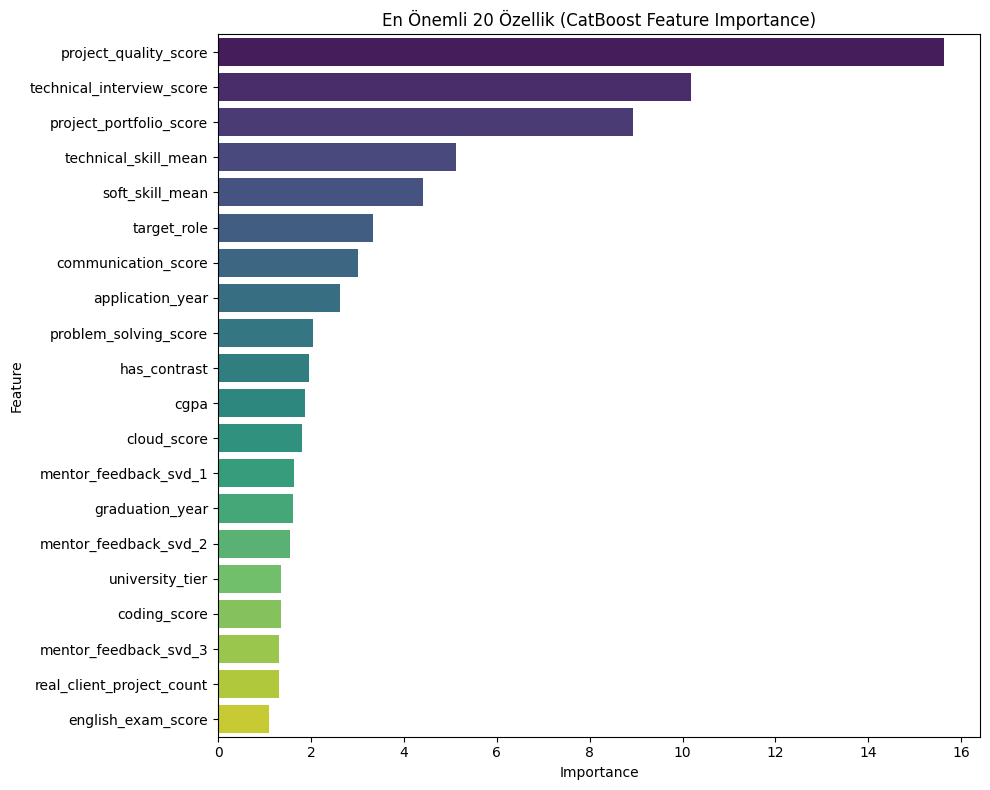


EN GEREKSİZ (DÜŞÜK ÖNEMLİ) 15 ÖZELLİK
                                   Feature  Importance
                                department    0.167299
                                     hobby    0.137095
                          internship_count    0.111889
                         age_at_graduation    0.111188
           preferred_social_media_platform    0.100007
                      soft_criticism_score    0.094784
               portfolio_score_was_missing    0.081520
            hr_interview_score_was_missing    0.030565
        linkedin_profile_score_was_missing    0.012718
                    years_since_graduation    0.011397
    internship_duration_months_was_missing    0.009139
            english_exam_score_was_missing    0.005288
open_source_contribution_count_was_missing    0.003258
                        is_recent_graduate    0.000000
              github_avg_stars_was_missing    0.000000

ÇÖPE ATILACAK ÖZELLİK SAYISI: 10
['soft_criticism_score', 'portfolio_score_was_m

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor

# 1. Modeli tüm veriyle eğitip Özellik Önemini (Feature Importance) çıkaralım
print("Özellik önem dereceleri hesaplanıyor. Lütfen bekleyin...")
fs_model = CatBoostRegressor(
    iterations=1000, 
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False # Çıktı kalabalığı yapmaması için kapattık
)

# X, y ve cat_feature_indices zaten önceki hücrelerden hafızada var
fs_model.fit(X, y, cat_features=cat_feature_indices)

# 2. Önem Derecelerini DataFrame'e Çevirme
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': fs_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

# 3. Görselleştirme: En Önemli 20 Özellik
plt.figure(figsize=(10, 8))
plt.title("En Önemli 20 Özellik (CatBoost Feature Importance)")
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(20), palette='viridis')
plt.tight_layout()
plt.show()

# 4. En Kötü Özellikleri Görelim
print("\n" + "="*50)
print("EN GEREKSİZ (DÜŞÜK ÖNEMLİ) 15 ÖZELLİK")
print("="*50)
print(feature_importances.tail(15).to_string(index=False))

# 5. Gürültüyü Temizleme (Threshold Belirleme)
# Önem derecesi %0.1'in altında olan (modele hiçbir katkısı olmayan) sütunları belirliyoruz
THRESHOLD = 0.1 
useless_features = feature_importances[feature_importances['Importance'] < THRESHOLD]['Feature'].tolist()

print("\n" + "="*50)
print(f"ÇÖPE ATILACAK ÖZELLİK SAYISI: {len(useless_features)}")
print("="*50)
print(useless_features)

# 6. Temizlenmiş Yeni Veri Setlerini Oluşturma
X_clean = X.drop(columns=useless_features)
X_test_clean = X_test.drop(columns=useless_features)

# Modeller için yeni kategorik indeksleri güncelleme
cat_cols_clean = [c for c in cat_cols if c in X_clean.columns]
cat_feature_indices_clean = [X_clean.columns.get_loc(c) for c in cat_cols_clean]

print("\n" + "="*50)
print(f"Eski Sütun Sayısı: {X.shape[1]}")
print(f"Yeni (Temiz) Sütun Sayısı: {X_clean.shape[1]}")
print("Feature Selection Tamamlandı! Artık X_clean ve X_test_clean ile yola devam edebiliriz.")
print("="*50)

In [45]:
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

# 1. Kategorik Kolonları Güvenli Hale Getirme
cat_cols_clean = [c for c in cat_cols if c in X_clean.columns]
for col in cat_cols_clean:
    X_clean[col] = X_clean[col].astype('category')
    X_test_clean[col] = X_test_clean[col].astype('category')

cat_feature_indices_clean = [X_clean.columns.get_loc(c) for c in cat_cols_clean]

# 2. Modellerin Silahlarını Kuşanması
cat_model = CatBoostRegressor(
    iterations=1500, learning_rate=0.03, depth=6,
    l2_leaf_reg=6, random_seed=42, verbose=False
)

lgbm_model = lgb.LGBMRegressor(
    n_estimators=1500, learning_rate=0.03, max_depth=6,
    random_state=42, verbose=-1
)

xgb_model = XGBRegressor(
    n_estimators=1500, learning_rate=0.03, max_depth=6,
    random_state=42, enable_categorical=True, tree_method='hist',
    early_stopping_rounds=150
)

# 3. K-Fold CV ve Ensemble (Ortak Akıl) Eğitimi
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Test seti tahminlerini tutacak boş diziler
cat_test_preds = np.zeros(len(X_test_clean))
lgbm_test_preds = np.zeros(len(X_test_clean))
xgb_test_preds = np.zeros(len(X_test_clean))

print("=== 🚀 KUTSAL İTTİFAK (ENSEMBLE) EĞİTİMİ BAŞLIYOR ===")

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_clean, y), start=1):
    print(f"\n--- Fold {fold} Çalışıyor ---")
    X_tr, X_val = X_clean.iloc[train_idx], X_clean.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    # CatBoost Eğitimi
    cat_model.fit(X_tr, y_tr, cat_features=cat_feature_indices_clean, eval_set=(X_val, y_val), early_stopping_rounds=150, verbose=False)
    cat_pred = cat_model.predict(X_val)
    cat_test_preds += cat_model.predict(X_test_clean) / 5

    # LightGBM Eğitimi
    lgbm_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(150, verbose=False)])
    lgbm_pred = lgbm_model.predict(X_val)
    lgbm_test_preds += lgbm_model.predict(X_test_clean) / 5

    # XGBoost Eğitimi
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_pred = xgb_model.predict(X_val)
    xgb_test_preds += xgb_model.predict(X_test_clean) / 5

    print(f"CatBoost RMSE: {mean_squared_error(y_val, cat_pred)**0.5:.4f} | LGBM: {mean_squared_error(y_val, lgbm_pred)**0.5:.4f} | XGB: {mean_squared_error(y_val, xgb_pred)**0.5:.4f}")

# 4. Ensemble: Ortalamayı Alma İşlemi
print("\n=== 🧠 TAHMİNLER BİRLEŞTİRİLİYOR ===")
# Üç uzman modelin tahminlerinin aritmetik ortalamasını alıyoruz
final_preds = (cat_test_preds + lgbm_test_preds + xgb_test_preds) / 3
final_preds_clipped = np.clip(final_preds, 0, 100)

# 5. Sisteme Yüklenecek Dosyanın Hazırlanması
submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET: final_preds_clipped})
submission.to_csv("submission_ensemble_cleaned.csv", index=False)
print("✅ İşlem Tamam! 'submission_ensemble_cleaned.csv' dosyası Leaderboard'a gönderilmeye hazır.")

=== 🚀 KUTSAL İTTİFAK (ENSEMBLE) EĞİTİMİ BAŞLIYOR ===

--- Fold 1 Çalışıyor ---
CatBoost RMSE: 8.9917 | LGBM: 9.2190 | XGB: 9.2984

--- Fold 2 Çalışıyor ---
CatBoost RMSE: 9.1621 | LGBM: 9.3375 | XGB: 9.3581

--- Fold 3 Çalışıyor ---
CatBoost RMSE: 8.5588 | LGBM: 8.6343 | XGB: 8.7641

--- Fold 4 Çalışıyor ---
CatBoost RMSE: 8.6391 | LGBM: 8.6828 | XGB: 8.7330

--- Fold 5 Çalışıyor ---
CatBoost RMSE: 8.9977 | LGBM: 9.1602 | XGB: 9.2005

=== 🧠 TAHMİNLER BİRLEŞTİRİLİYOR ===
✅ İşlem Tamam! 'submission_ensemble_cleaned.csv' dosyası Leaderboard'a gönderilmeye hazır.


- Select only first 35 Feature
- Weighted ensemble among the 3 models

In [46]:
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

# ==========================================
# 1. AGRESİF ÖZELLİK SEÇİMİ (Sadece Elit 35)
# ==========================================
TOP_N = 35

# Bir önceki hücreden 'feature_importances' tablosu hafızada duruyor
best_features = feature_importances.head(TOP_N)['Feature'].tolist()

X_elite = X[best_features].copy()
X_test_elite = X_test[best_features].copy()

# Kategorik değişkenleri yeni elit listeye göre ayarla
cat_cols_elite = [c for c in cat_cols if c in X_elite.columns]

for col in cat_cols_elite:
    X_elite[col] = X_elite[col].astype('category')
    X_test_elite[col] = X_test_elite[col].astype('category')

cat_feature_indices_elite = [X_elite.columns.get_loc(c) for c in cat_cols_elite]

print("="*50)
print(f"🧹 AGRESİF TEMİZLİK: Sütun sayısı {X.shape[1]}'den {X_elite.shape[1]}'e düşürüldü!")
print("="*50)

# ==========================================
# 2. MODELLER (Aynı Güçlü Ayarlarla)
# ==========================================
cat_model = CatBoostRegressor(
    iterations=1500, learning_rate=0.03, depth=6,
    l2_leaf_reg=6, random_seed=42, verbose=False
)

lgbm_model = lgb.LGBMRegressor(
    n_estimators=1500, learning_rate=0.03, max_depth=6,
    random_state=42, verbose=-1
)

xgb_model = XGBRegressor(
    n_estimators=1500, learning_rate=0.03, max_depth=6,
    random_state=42, enable_categorical=True, tree_method='hist',
    early_stopping_rounds=150
)

# ==========================================
# 3. K-FOLD EĞİTİM
# ==========================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cat_test_preds = np.zeros(len(X_test_elite))
lgbm_test_preds = np.zeros(len(X_test_elite))
xgb_test_preds = np.zeros(len(X_test_elite))

cat_scores, lgbm_scores, xgb_scores = [], [], []

print("🚀 ELİT VERİ İLE EĞİTİM BAŞLIYOR...")

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_elite, y), start=1):
    X_tr, X_val = X_elite.iloc[train_idx], X_elite.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    # CatBoost
    cat_model.fit(X_tr, y_tr, cat_features=cat_feature_indices_elite, eval_set=(X_val, y_val), early_stopping_rounds=150, verbose=False)
    cat_pred = cat_model.predict(X_val)
    cat_scores.append(mean_squared_error(y_val, cat_pred)**0.5)
    cat_test_preds += cat_model.predict(X_test_elite) / 5

    # LightGBM
    lgbm_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(150, verbose=False)])
    lgbm_pred = lgbm_model.predict(X_val)
    lgbm_scores.append(mean_squared_error(y_val, lgbm_pred)**0.5)
    lgbm_test_preds += lgbm_model.predict(X_test_elite) / 5

    # XGBoost
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_pred = xgb_model.predict(X_val)
    xgb_scores.append(mean_squared_error(y_val, xgb_pred)**0.5)
    xgb_test_preds += xgb_model.predict(X_test_elite) / 5

    print(f"Fold {fold} -> Cat: {cat_scores[-1]:.4f} | LGBM: {lgbm_scores[-1]:.4f} | XGB: {xgb_scores[-1]:.4f}")

print("\n--- ORTALAMA CV RMSE ---")
print(f"CatBoost: {np.mean(cat_scores):.4f} | LGBM: {np.mean(lgbm_scores):.4f} | XGB: {np.mean(xgb_scores):.4f}")

# ==========================================
# 4. AĞIRLIKLI (WEIGHTED) ENSEMBLE
# ==========================================
print("\n=== 🧠 AĞIRLIKLI TAHMİNLER BİRLEŞTİRİLİYOR ===")
# CatBoost'a %60, LGBM'e %25, XGBoost'a %15 ağırlık veriyoruz
final_preds = (cat_test_preds * 0.60) + (lgbm_test_preds * 0.25) + (xgb_test_preds * 0.15)
final_preds_clipped = np.clip(final_preds, 0, 100)

submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET: final_preds_clipped})
submission_name = "submission_weighted_elite35.csv"
submission.to_csv(submission_name, index=False)
print(f"✅ İşlem Tamam! '{submission_name}' dosyası Leaderboard'a gönderilmeye hazır.")

🧹 AGRESİF TEMİZLİK: Sütun sayısı 77'den 35'e düşürüldü!
🚀 ELİT VERİ İLE EĞİTİM BAŞLIYOR...
Fold 1 -> Cat: 9.0931 | LGBM: 9.2664 | XGB: 9.3296
Fold 2 -> Cat: 9.2017 | LGBM: 9.3486 | XGB: 9.4136
Fold 3 -> Cat: 8.5989 | LGBM: 8.7616 | XGB: 8.7995
Fold 4 -> Cat: 8.5897 | LGBM: 8.6967 | XGB: 8.7240
Fold 5 -> Cat: 9.0562 | LGBM: 9.1914 | XGB: 9.2658

--- ORTALAMA CV RMSE ---
CatBoost: 8.9079 | LGBM: 9.0530 | XGB: 9.1065

=== 🧠 AĞIRLIKLI TAHMİNLER BİRLEŞTİRİLİYOR ===
✅ İşlem Tamam! 'submission_weighted_elite35.csv' dosyası Leaderboard'a gönderilmeye hazır.


# Optuna with 67 features 

In [ ]:
import optuna
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")

print("=== 🤖 OPTUNA İLE YAPAY ZEKA DESTEKLİ OPTİMİZASYON BAŞLIYOR ===")
print("NOT: Bu işlem bilgisayarının hızına göre 5-10 dakika sürebilir. Arkana yaslan ve bekle!\n")

# CatBoost'un kategorik indeksleri (67 sütunlu temiz veri için)
cat_cols_clean = [c for c in cat_cols if c in X_clean.columns]
cat_feature_indices_clean = [X_clean.columns.get_loc(c) for c in cat_cols_clean]

def objective(trial):
    # 1. Optuna'nın deneyeceği parametre aralıkları
    param = {
        "iterations": trial.suggest_int("iterations", 1000, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": False
    }
    
    # 2. Hızlı bir K-Fold (Bu sefer hız için 3 Fold yapıyoruz)
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    
    for train_idx, valid_idx in kf.split(X_clean, y):
        X_tr, X_val = X_clean.iloc[train_idx], X_clean.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        
        model = CatBoostRegressor(**param)
        model.fit(X_tr, y_tr, cat_features=cat_feature_indices_clean, 
                  eval_set=(X_val, y_val), early_stopping_rounds=100, verbose=False)
        
        preds = model.predict(X_val)
        rmse = mean_squared_error(y_val, preds) ** 0.5
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

# 3. Optuna'yı Çalıştır (20 farklı kombinasyon deneyecek)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20) # Vaktin varsa n_trials=50 yapabilirsin

print("\n" + "="*50)
print(f"🎉 EN İYİ SKOR (CV RMSE): {study.best_value:.5f}")
print("="*50)
print("EN İYİ PARAMETRELER:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

# ==========================================
# 4. EN İYİ PARAMETRELERLE NİHAİ MODEL EĞİTİMİ
# ==========================================
print("\nBulunan en iyi parametrelerle nihai model eğitiliyor...")

best_params = study.best_params
best_params.update({"loss_function": "RMSE", "eval_metric": "RMSE", "random_seed": 42, "verbose": False})

final_model = CatBoostRegressor(**best_params)
final_model.fit(X_clean, y, cat_features=cat_feature_indices_clean)

# Test seti tahminleri ve sisteme uygun kırpma
final_preds = final_model.predict(X_test_clean)
final_preds_clipped = np.clip(final_preds, 0, 100)

submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET: final_preds_clipped})
submission.to_csv("submission_OPTUNA_CatBoost.csv", index=False)

print("✅ Mükemmel parametreli 'submission_OPTUNA_CatBoost.csv' hazır!")

[I 2026-06-12 16:20:17,105] A new study created in memory with name: no-name-1a2edd81-1003-4e85-8e5e-f51faa2416de


=== 🤖 OPTUNA İLE YAPAY ZEKA DESTEKLİ OPTİMİZASYON BAŞLIYOR ===
NOT: Bu işlem bilgisayarının hızına göre 5-10 dakika sürebilir. Arkana yaslan ve bekle!



[I 2026-06-12 16:21:42,284] Trial 0 finished with value: 9.016141354487516 and parameters: {'iterations': 1444, 'learning_rate': 0.08294853814428847, 'depth': 7, 'l2_leaf_reg': 1.9707452414637667, 'random_strength': 5.037782607199344, 'bagging_temperature': 0.33139978513186263}. Best is trial 0 with value: 9.016141354487516.
[I 2026-06-12 16:25:49,924] Trial 1 finished with value: 8.973305604964485 and parameters: {'iterations': 1277, 'learning_rate': 0.021625761333134964, 'depth': 7, 'l2_leaf_reg': 2.522378912863041, 'random_strength': 3.4056545115948276, 'bagging_temperature': 0.2736515938113153}. Best is trial 1 with value: 8.973305604964485.
[I 2026-06-12 16:28:44,149] Trial 2 finished with value: 8.94376035606139 and parameters: {'iterations': 2158, 'learning_rate': 0.037047130225704876, 'depth': 6, 'l2_leaf_reg': 7.082792287588878, 'random_strength': 1.8295737147461442, 'bagging_temperature': 0.8504625483978394}. Best is trial 2 with value: 8.94376035606139.
[I 2026-06-12 16:31:5